### **CC57 - MACHINE LEARNING - CLASIFICADOR NAIVE BAYES**

# Detección de fraude con tarjetas de crédito


El conjunto de datos contiene transacciones validas y fraudelentas en realizadas con tarjeta de credito.  

Son 9965 observaciones en 31 variables.
Se desconoce los nombres de las variables ( van del V1 al V28), por tanto, no se sabe que valores representan.

El atributo Time representa la hora en cantidad de segundos, por tanto, habra que convertirlo a horas.

La variable Amount contiene el valor de la transaccion y la variable Class es la eqiqueta o variable objetivo (0 = transaccion real, 1= transaccion fraudulenta).

Se solicita lo siguiente:

- Cargar los datos
- Realizar un analisis visual y preprocesamiento de los datos
- Crear un modelo utilizando el clasificador Naive Bayes (GaussianNB) para predecir si una transaccion con TC en genuina o fraudulenta.  

- Visualizar los resultados del modelo
- Evaluar el modelo



## <font color=blue>0. Cargar Librerias</font>


In [65]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## <font color=blue>1. Analisis Exploratorio de los Datos</font>


In [66]:
#Cargar archivo de datos
df = pd.read_csv("tcredito.csv")
df.shape

(284807, 31)

In [67]:
#Visualizar primeros registros del conjunto de datos
df.head()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [68]:
#valores nulos
df.isnull().sum().sum()


np.int64(0)

In [69]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

### **Análisis de las medidas de tendencia/estadistica**

In [70]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


### **Visualizacion de los atributos de clase reales y fraudulentos**

Cantidad de transacciones reales:  492
Cantidad de transacciones fraudulentas:  284315


/tmp/ipykernel_361316/2049776272.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=df, palette='Set1', ax=ax)


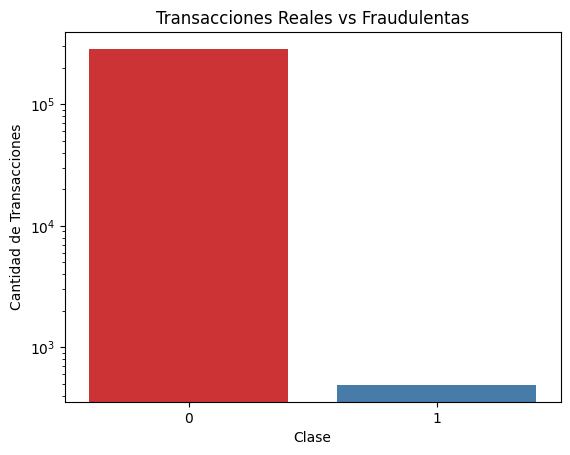

In [71]:
df_reales = df[df['Class'] == 1]
df_fraude = df[df['Class'] == 0]
#Visualizar la cantidad de transacciones fraudulentas y reales

print("Cantidad de transacciones reales: ", df_reales.shape[0])
print("Cantidad de transacciones fraudulentas: ", df_fraude.shape[0])

fig, ax = plt.subplots()
sns.countplot(x='Class', data=df, palette='Set1', ax=ax)

plt.title('Transacciones Reales vs Fraudulentas')
plt.xlabel('Clase')
plt.ylabel('Cantidad de Transacciones')
ax.set_yscale('log')
plt.show()

In [72]:
df['Time'].max()/(60*60) 
# Nos indican que el tiempo esta segundos, en horas son 48 supondre que son dos dias de registros

np.float64(47.99777777777778)

/tmp/ipykernel_361316/13895116.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Hour48', data=df, palette='Set1', ax=ax)


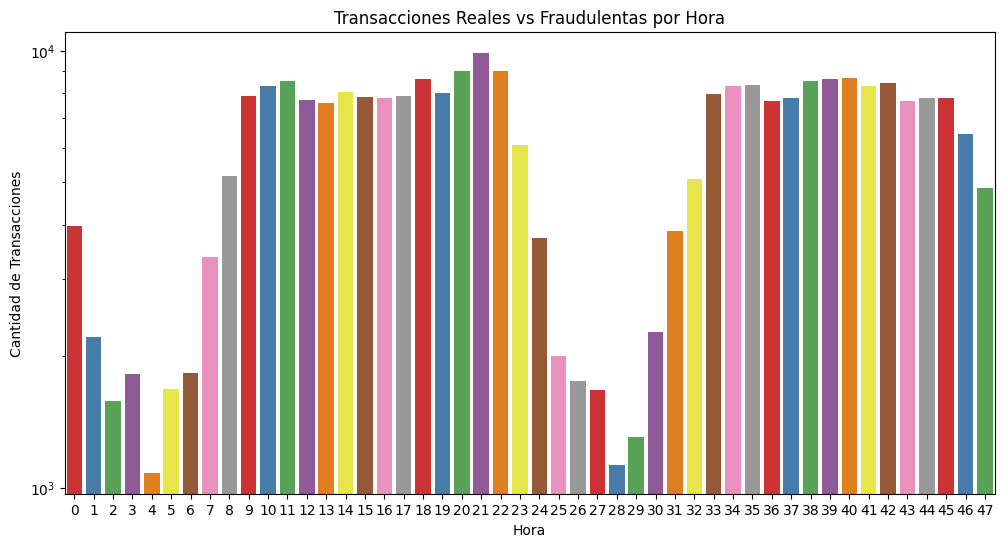

In [73]:
df['Hour48'] = df['Time'].apply(lambda x: (x/3600))
df['Hour48'] = df['Hour48'].astype(int)
#Visualizar la cantidad de transacciones fraudulentas y reales por hora
fig, ax = plt.subplots(figsize=(12, 6))
sns.countplot(x='Hour48', data=df, palette='Set1', ax=ax)
plt.title('Transacciones Reales vs Fraudulentas por Hora')
plt.xlabel('Hora')
plt.ylabel('Cantidad de Transacciones')
ax.set_yscale('log')
plt.show()

Se distinguen dos ciclos temporales, se valida la hipotesis de que son dos dias

/tmp/ipykernel_361316/3882188756.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Hour', data=df, palette='Set1', ax=ax)


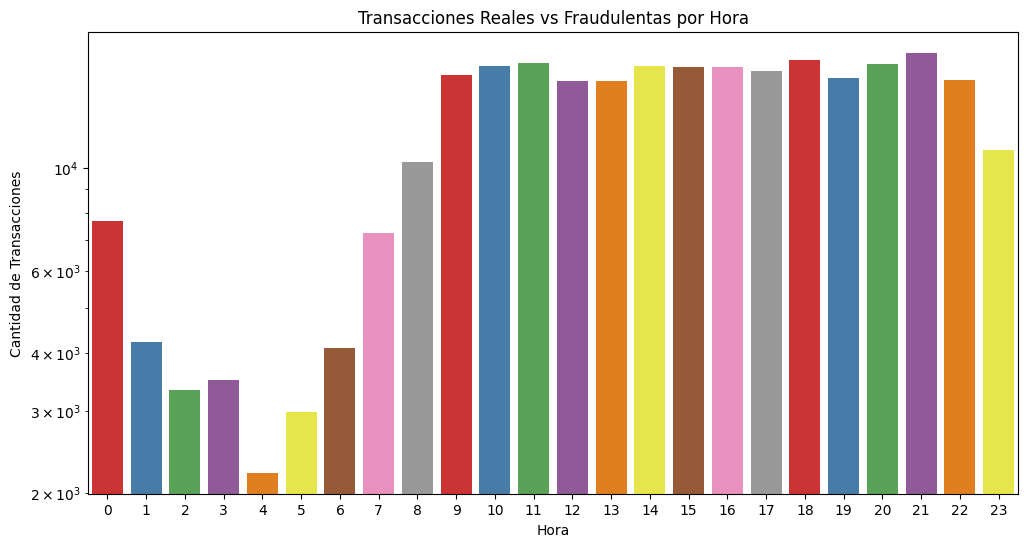

In [74]:
df['Hour'] = df['Time'].apply(lambda x: (x/3600)%24)
df['Hour'] = df['Hour'].astype(int)
#Visualizar la cantidad de transacciones fraudulentas y reales por hora
fig, ax = plt.subplots(figsize=(12, 6))
sns.countplot(x='Hour', data=df, palette='Set1', ax=ax)
plt.title('Transacciones Reales vs Fraudulentas por Hora')
plt.xlabel('Hora')
plt.ylabel('Cantidad de Transacciones')
ax.set_yscale('log')
plt.show()

## <font color=blue>2. Preprocesamiento de los datos</font>

### **Verificar datos faltantes y/o duplicados**

In [75]:
df.isnull().sum().sum() # sin nulls

np.int64(0)

Ahora validemos las variables de razon, donde un 0 involucraria que la inexistencia de la variable

In [76]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class', 'Hour48', 'Hour'],
      dtype='object')

Identificamos a Amount como variable de razon, ya que una transaccion debe estar asociada a un monto

In [77]:
print(f'Negativos {df[df["Amount"]<0].shape[0]}')
print(f'Transacciones invalidas {df[df["Amount"]==0].shape[0]}')
print(f'Representan el {df[df["Amount"]==0].shape[0]/df.shape[0]*100:.2f}% del total')

Negativos 0
Transacciones invalidas 1825
Representan el 0.64% del total


In [78]:
# las matamos
df = df[(df['Amount'] != 0)]

<Axes: >

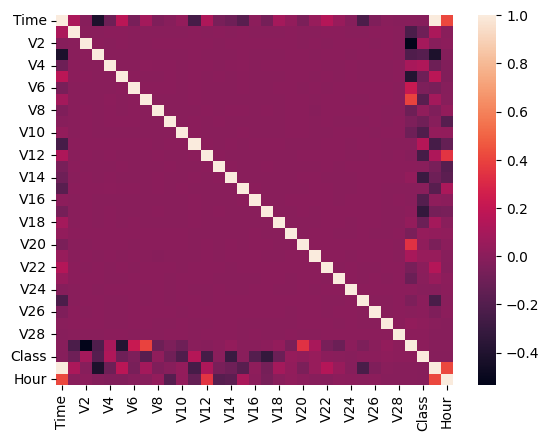

In [79]:
corr = df[df.columns].corr()
sns.heatmap(corr, annot=False) #xd 

En efecto es cine

### **Separar variables predictoras y el atributo destino de los datos**

In [80]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class', 'Hour48', 'Hour'],
      dtype='object')

In [81]:
Y = df['Class']
X = df.drop(['Class', 'Time', 'Hour48'], axis=1) # la hora es relevante, asi que la dejamos
X

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Hour
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,4.356170,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,23
284803,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,-0.975926,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,23
284804,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,-0.484782,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,23
284805,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,-0.399126,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,23


In [82]:
from sklearn.preprocessing import StandardScaler

#Estandarizamos las variables predictoras

rescalarX = StandardScaler().fit_transform(X)
dataX = pd.DataFrame(data=rescalarX, columns=X.columns)
dataX.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Hour
0,-0.694755,-0.042875,1.677200,0.989532,-0.243746,0.348224,0.192140,0.082835,0.329666,0.085578,...,-0.024920,0.385138,-0.177553,0.110148,0.247698,-0.389581,0.330793,-0.064313,0.242005,-2.408778
1,0.609280,0.162478,0.112120,0.327538,0.045153,-0.060872,-0.065897,0.071421,-0.233736,-0.151433,...,-0.308096,-0.878013,0.162336,-0.561325,0.321848,0.264064,-0.022921,0.043988,-0.343785,-2.408778
2,-0.694012,-0.810758,1.173218,0.278868,-0.363325,1.353122,0.639377,0.207903,-1.379470,0.193017,...,0.338562,1.065760,1.459422,-1.138146,-0.627916,-0.285793,-0.137987,-0.181457,1.155155,-2.408778
3,-0.493637,-0.111003,1.186283,-0.605977,-0.005852,0.937607,0.190528,0.316838,-1.263343,-0.048432,...,-0.147754,0.009485,-0.305712,-1.940885,1.243576,-0.457670,0.155016,0.185454,0.137868,-2.408778
4,-0.591740,0.533027,1.024962,0.295420,-0.293697,0.073014,0.478493,-0.227138,0.742703,0.694525,...,-0.012805,1.102420,-0.220865,0.232862,-0.394449,1.045090,0.543862,0.650704,-0.075469,-2.408778


In [83]:
dataX.describe()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Hour
count,2.829820e+05,2.829820e+05,2.829820e+05,2.829820e+05,2.829820e+05,2.829820e+05,2.829820e+05,2.829820e+05,2.829820e+05,2.829820e+05,...,2.829820e+05,2.829820e+05,2.829820e+05,2.829820e+05,2.829820e+05,2.829820e+05,2.829820e+05,2.829820e+05,2.829820e+05,2.829820e+05
mean,-2.008729e-18,1.124888e-17,-9.641900e-18,-2.330126e-17,8.838408e-18,1.426198e-17,2.008729e-19,1.155019e-18,3.427394e-18,-7.130988e-18,...,-9.340590e-18,4.338855e-17,9.240154e-18,9.842773e-18,4.740601e-17,8.838408e-18,2.912657e-18,4.017458e-19,2.892570e-17,-1.671263e-16
std,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,...,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00
min,-2.882703e+01,-4.405591e+01,-3.191247e+01,-4.036869e+00,-8.249207e+01,-1.964510e+01,-3.530141e+01,-6.146622e+01,-1.212093e+01,-2.260610e+01,...,-4.754029e+01,-1.506605e+01,-7.191919e+01,-4.682826e+00,-1.976046e+01,-5.401614e+00,-5.599690e+01,-4.670878e+01,-3.544694e-01,-2.408778e+00
25%,-4.700553e-01,-3.636925e-01,-5.879967e-01,-5.986907e-01,-5.015228e-01,-5.765494e-01,-4.492821e-01,-1.754367e-01,-5.861989e-01,-4.918016e-01,...,-3.124711e-01,-7.475199e-01,-2.598438e-01,-5.858672e-01,-6.087388e-01,-6.775600e-01,-1.762852e-01,-1.606820e-01,-3.306279e-01,-6.949037e-01
50%,8.810319e-03,3.933979e-02,1.193700e-01,-9.940753e-03,-3.864042e-02,-2.068015e-01,3.196767e-02,1.803429e-02,-4.729556e-02,-8.555066e-02,...,-4.095736e-02,9.081895e-03,-1.800638e-02,6.731759e-02,3.099441e-02,-1.099332e-01,2.695740e-03,3.367702e-02,-2.648448e-01,1.620332e-01
75%,6.724330e-01,4.880378e-01,6.777473e-01,5.289930e-01,4.442767e-01,2.968776e-01,4.614963e-01,2.742905e-01,5.436369e-01,4.148040e-01,...,2.542118e-01,7.285962e-01,2.373491e-01,7.259748e-01,6.734151e-01,5.001303e-01,2.260548e-01,2.368568e-01,-4.353413e-02,8.475827e-01
max,1.254777e+00,1.336560e+01,6.198499e+00,1.202076e+01,2.524195e+01,5.504920e+01,9.772533e+01,1.679624e+01,1.418807e+01,2.183506e+01,...,3.712951e+01,1.447778e+01,3.615914e+01,7.567505e+00,1.443440e+01,7.301330e+00,7.844439e+01,1.024597e+02,1.020726e+02,1.533132e+00


### **Seleccionar las 10 mejores características para construir modelos**

Utilizar:

from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif

In [84]:
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif

# Seleccionamos las 10 mejores variables predictoras
selector = SelectKBest(score_func=f_classif, k=10)
X_new = selector.fit_transform(dataX, Y)
X_new.shape


(282982, 10)

## Visualización de las mejores y malas características

In [85]:
# Visualizamos las mejores variables
mask = selector.get_support()
X_new = dataX.loc[:, mask]
X_new.columns


Index(['V3', 'V4', 'V7', 'V10', 'V11', 'V12', 'V14', 'V16', 'V17', 'V18'], dtype='object')

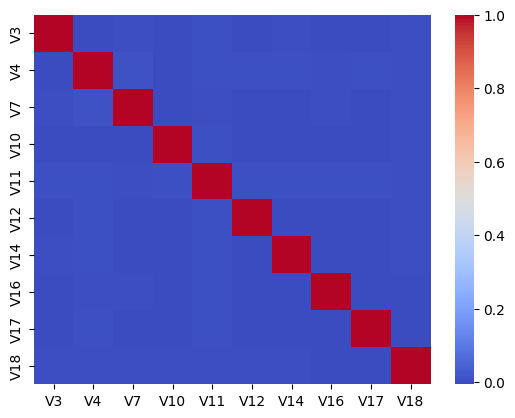

In [86]:
# Visualizamos la correlación entre las mejores variables 
corr = X_new.corr()
sns.heatmap(corr, annot=False, cmap='coolwarm')
plt.show()

## <font color=blue>3. Entrenando el modelo </font>

### **Dividir el conjunto de datos en una proporción de 80: 20**

In [87]:
# Dividimos el conjunto de datos en entrenamiento y prueba 80-20
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X_new, Y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape, Y_train.shape, Y_test.shape


((226385, 10), (56597, 10), (226385,), (56597,))

In [88]:

# Guardamos los conjuntos de datos
X_train.to_csv('X_train.csv', index=False)
X_test.to_csv('X_test.csv', index=False)
Y_train.to_csv('Y_train.csv', index=False)
Y_test.to_csv('Y_test.csv', index=False)

### Validación cruzada de los datos de entrenamiento

Debido a que los datos están muy desequilibrados, utilizaremos validación cruzada.
* Dividir el conjunto de datos en conjuntos de datos de entrenamiento y prueba.
* Entrene el modelo usando un conjunto de datos de entrenamiento.
* Pruebe el modelo en el conjunto de datos de prueba.

In [89]:
from sklearn.naive_bayes import GaussianNB

# Crear un objeto Gaussiano Naive Bayes
gnb = GaussianNB()
# Entrenar el modelo
gnb.fit(X_train, Y_train)
# Predecir las etiquetas para el conjunto de prueba
Y_pred = gnb.predict(X_test)


## <font color=blue>4. Evaluación y visualización del modelo </font>
<br>

In [90]:

# Calcular la precisión del modelo
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
print("Precisión del modelo: ", accuracy_score(Y_test, Y_pred))

Precisión del modelo:  0.9909359153312013


In [91]:
# Matriz de confusión
cm = confusion_matrix(Y_test, Y_pred)
cm

array([[56012,   505],
       [    8,    72]])

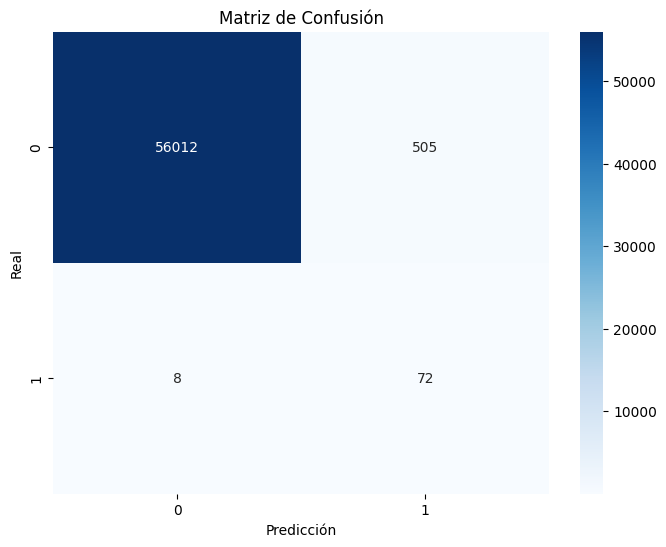

In [92]:

# Visualizar la matriz de confusión
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()


In [93]:

# Reporte de clasificación
print(classification_report(Y_test, Y_pred))
# Guardar el modelo
import joblib
joblib.dump(gnb, 'modelo_gnb.pkl')
# Cargar el modelo
gnb = joblib.load('modelo_gnb.pkl')
# Cargar el modelo
# Predecir las etiquetas para el conjunto de prueba
Y_pred = gnb.predict(X_test)
# Calcular la precisión del modelo
print("Precisión del modelo: ", accuracy_score(Y_test, Y_pred))

# cv_results almacena la puntuación del tren y el estimador


              precision    recall  f1-score   support

           0       1.00      0.99      1.00     56517
           1       0.12      0.90      0.22        80

    accuracy                           0.99     56597
   macro avg       0.56      0.95      0.61     56597
weighted avg       1.00      0.99      0.99     56597

Precisión del modelo:  0.9909359153312013


## **Precision de los datos de entrenamiento**

In [94]:
#precision datos de entreno 
from sklearn.metrics import precision_score, recall_score, f1_score
print("Precision: ", precision_score(Y_test, Y_pred))
print("Recall: ", recall_score(Y_test, Y_pred))
print("F1 Score: ", f1_score(Y_test, Y_pred))

Precision:  0.12478336221837089
Recall:  0.9
F1 Score:  0.2191780821917808
